# Notebook 02 – Statistical Analysis (ANOVA)
IITB Project – Problem ID-9: Effect of Feedback on Affective and Cognitive Measures

## Goals of This Notebook
1. Load preprocessed trial-level features from preprocessed_features.csv.
2. Perform descriptive statistics for affective and cognitive measures.
3. Conduct ANOVA tests to examine the effect of feedback type on:
   - Engagement
   - Confusion
   - EEG band powers (delta, theta, alpha, beta, gamma)
4. Visualize results with:
   - Boxplots
   - Bar charts
   - Error bars for statistical comparisons
5. Save ANOVA summary tables and plots for reporting.

## Input Data
- preprocessed_features.csv → trial-level dataset with extracted features

## Output
- anova_summary.csv → ANOVA statistics per feature  
- anova_plots/ → figures showing feature distributions and comparisons


Data loaded. Shape: (1448, 186)


,participant,trial_id,feedback,feedback_time,engagement,confusion,Delta_TP9_delta,Delta_TP9_theta,Delta_TP9_alpha,Delta_TP9_beta,...,HSI_AF8_delta,HSI_AF8_theta,HSI_AF8_alpha,HSI_AF8_beta,HSI_AF8_gamma,HSI_TP10_delta,HSI_TP10_theta,HSI_TP10_alpha,HSI_TP10_beta,HSI_TP10_gamma
0,1,1spl1,CORRECT,NaN,0.328766,0.001464,30423.832453,1001.576857,534.120623,114.120591,...,2.300533e-26,1.704066e-26,4.187869e-27,3.137099e-28,1.416536e-28,169695.218012,9305.244911,2869.478148,822.811838,231.946762
1,1,1spl2,CORRECT,NaN,0.328766,0.001753,30423.832453,1001.576857,534.120623,114.120591,...,2.300533e-26,1.704066e-26,4.187869e-27,3.137099e-28,1.416536e-28,169695.218012,9305.244911,2869.478148,822.811838,231.946762
2,1,1Item1,CORRECT,NaN,0.328766,0.001485,30423.832453,1001.576857,534.120623,114.120591,...,2.300533e-26,1.704066e-26,4.187869e-27,3.137099e-28,1.416536e-28,169695.218012,9305.244911,2869.478148,822.811838,231.946762
3,1,1Item2,CORRECT,NaN,0.328766,0.001672,30423.832453,1001.576857,534.120623,114.120591,...,2.300533e-26,1.704066e-26,4.187869e-27,3.137099e-28,1.416536e-28,169695.218012,9305.244911,2869.478148,822.811838,231.946762
4,1,1Item3,CORRECT,NaN,0.328766,0.001729,30423.832453,1001.576857,534.120623,114.120591,...,2.300533e-26,1.704066e-26,4.187869e-27,3.137099e-28,1.416536e-28,169695.218012,9305.244911,2869.478148,822.811838,231.946762


Trials after filtering: (1410, 186)

📊 Group Means (Engagement & Confusion):
            engagement  confusion
feedback                        
CORRECT     17.051485   0.651196
INCORRECT   20.229935   1.115852
SKIP        25.725677   0.990914

📈 ANOVA for engagement:
                   sum_sq      df         F    PR(>F)
C(feedback)  4.794792e+03     2.0  2.939785  0.053202
Residual     1.147409e+06  1407.0       NaN       NaN

📈 ANOVA for confusion:
                   sum_sq      df         F    PR(>F)
C(feedback)     56.210194     2.0  3.655393  0.026097
Residual     10817.953213  1407.0       NaN       NaN

📈 ANOVA for delta:
                   sum_sq      df         F    PR(>F)
C(feedback)  2.976525e+17     2.0  0.163924  0.848823
Residual     1.277415e+21  1407.0       NaN       NaN

📈 ANOVA for theta:
                   sum_sq      df        F    PR(>F)
C(feedback)  8.449423e+15     2.0  0.18462  0.831441
Residual     3.219687e+19  1407.0      NaN       NaN

📈 ANOVA for alpha:
   

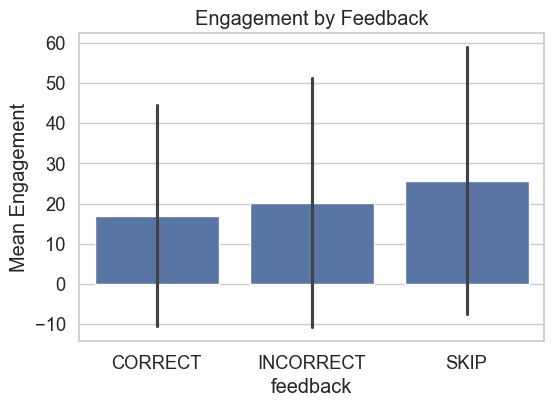

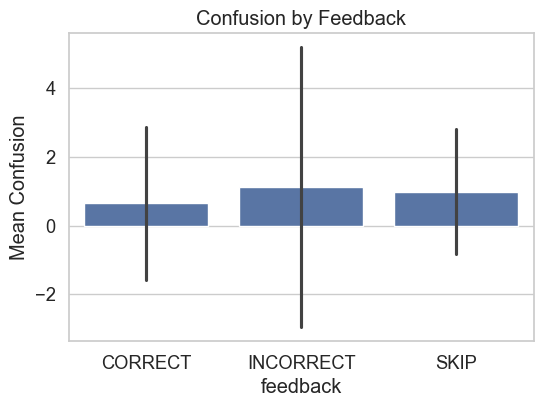


📂 Plots saved in: ..\results


In [4]:
# 02_anova_analysis

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import ols
from pathlib import Path

# -------------------------------
# Step 1: Load Preprocessed Data
# -------------------------------
data_path = Path("../results/preprocessed_features.csv")
df = pd.read_csv(data_path)
print("Data loaded. Shape:", df.shape)
display(df.head())

# -------------------------------
# Step 2: Filter Valid Trials
# -------------------------------
df = df[df["feedback"].notna()].copy()
df["feedback"] = df["feedback"].str.upper().str.strip()

affective_cols = ["engagement", "confusion"]
band_keywords = ["delta", "theta", "alpha", "beta", "gamma"]
eeg_cols = [c for c in df.columns if any(b in c.lower() for b in band_keywords)]

print(f"Trials after filtering: {df.shape}")

# -------------------------------
# Step 3: Group Means
# -------------------------------
summary = df.groupby("feedback")[affective_cols].mean()
print("\n📊 Group Means (Engagement & Confusion):\n", summary)

# -------------------------------
# Step 4: ANOVA Analysis
# -------------------------------
anova_results = {}

def run_anova(dep_var, label):
    try:
        model = ols(f"{dep_var} ~ C(feedback)", data=df).fit()
        anova_table = sm.stats.anova_lm(model, typ=2)
        anova_results[label] = anova_table
        print(f"\n📈 ANOVA for {label}:")
        print(anova_table)
    except Exception as e:
        print(f"⚠️ ANOVA failed for {label}: {e}")

# Affective states
for col in affective_cols:
    run_anova(col, col)

# EEG bands
for band in ["delta", "theta", "alpha", "beta", "gamma"]:
    band_cols = [c for c in eeg_cols if band in c.lower()]
    if not band_cols:
        continue
    df[f"{band}_mean"] = df[band_cols].mean(axis=1)
    run_anova(f"{band}_mean", band)

# -------------------------------
# Step 5: Save Results
# -------------------------------
out_dir = Path("../results")
out_dir.mkdir(parents=True, exist_ok=True)

anova_summary = pd.concat(anova_results, axis=0)
anova_path = out_dir / "anova_summary.csv"
anova_summary.to_csv(anova_path)

print(f"\n🎯 ANOVA results saved at: {anova_path}")

# -------------------------------
# Step 6: Visualizations
# -------------------------------
sns.set(style="whitegrid", font_scale=1.2)

plt.figure(figsize=(6, 4))
sns.barplot(x="feedback", y="engagement", data=df, errorbar="sd")
plt.title("Engagement by Feedback")
plt.ylabel("Mean Engagement")
plt.savefig(out_dir / "engagement_by_feedback.png", dpi=300)
plt.show()

plt.figure(figsize=(6, 4))
sns.barplot(x="feedback", y="confusion", data=df, errorbar="sd")
plt.title("Confusion by Feedback")
plt.ylabel("Mean Confusion")
plt.savefig(out_dir / "confusion_by_feedback.png", dpi=300)
plt.show()

print("\n📂 Plots saved in:", out_dir)
